### Importing libraries

In [46]:
import pandas as pd
import numpy as np
import seaborn as sns 
import matplotlib.pyplot as plt

### Loading data

In [47]:
orders = pd.read_parquet('../../data/groceries/orders.parquet')
regulars = pd.read_parquet('../../data/groceries/regulars.parquet')
abandoned_carts = pd.read_parquet('../../data/groceries/abandoned_carts.parquet')
inventory = pd.read_parquet('../../data/groceries/inventory.parquet')
users = pd.read_parquet('../../data/groceries/users.parquet')

### Hypotheses Proposed

**About products:**
- Which products are purchased most frequently?
- Which products are added most to regulars?
- Do users with more orders have more items in their regulars?
- Which products are abandoned most in the cart?
- Are the users who abandon the most also the most active ones?

**About users:**
- How loyal are users?
- Which users spend the most?
- Are there differences between Top Up vs Proposition segments?

**Hypotheses arising from the analysis:**
- How has sales volume evolved over time?
- Are users who fill in their household profile more loyal?
- What does the product catalogue tell us?

### Data Quality

#### Orders

In [48]:
orders.head()

,id,user_id,created_at,order_date,user_order_seq,ordered_items
10,2204073066628,62e271062eb827e411bd73941178d29b022f5f2de9d37f...,2020-04-30 14:32:19,2020-04-30,1,"[33618849693828, 33618860179588, 3361887404045..."
20,2204707520644,bf591c887c46d5d3513142b6a855dd7ffb9cc00697f6f5...,2020-04-30 17:39:00,2020-04-30,1,"[33618835243140, 33618835964036, 3361886244058..."
21,2204838822020,329f08c66abb51f8c0b8a9526670da2d94c0c6eef06700...,2020-04-30 18:12:30,2020-04-30,1,"[33618891145348, 33618893570180, 3361889766618..."
34,2208967852164,f6451fce7b1c58d0effbe37fcb4e67b718193562766470...,2020-05-01 19:44:11,2020-05-01,1,"[33618830196868, 33618846580868, 3361891234624..."
49,2215889436804,68e872ff888303bff58ec56a3a986f77ddebdbe5c279e7...,2020-05-03 21:56:14,2020-05-03,1,"[33667166699652, 33667166699652, 3366717122163..."


In [49]:
print(orders.info())
print(f'Null Records: {orders.isnull().sum()}')
print(f'Unique IDs: {orders.id.nunique()}')



<class 'pandas.core.frame.DataFrame'>
Index: 8773 entries, 10 to 64538
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   id              8773 non-null   int64         
 1   user_id         8773 non-null   object        
 2   created_at      8773 non-null   datetime64[us]
 3   order_date      8773 non-null   datetime64[us]
 4   user_order_seq  8773 non-null   int64         
 5   ordered_items   8773 non-null   object        
dtypes: datetime64[us](2), int64(2), object(2)
memory usage: 479.8+ KB
None
Null Records: id                0
user_id           0
created_at        0
order_date        0
user_order_seq    0
ordered_items     0
dtype: int64
Unique IDs: 8773


#### Regulars

In [50]:
regulars.head()

,user_id,variant_id,created_at
3,68e872ff888303bff58ec56a3a986f77ddebdbe5c279e7...,33618848088196,2020-04-30 15:07:03
11,aed88fc0b004270a62ff1fe4b94141f6b1db1496dbb0c0...,33667178659972,2020-05-05 23:34:35
18,68e872ff888303bff58ec56a3a986f77ddebdbe5c279e7...,33619009208452,2020-04-30 15:07:03
46,aed88fc0b004270a62ff1fe4b94141f6b1db1496dbb0c0...,33667305373828,2020-05-05 23:34:35
47,4594e99557113d5a1c5b59bf31b8704aafe5c7bd180b32...,33667247341700,2020-05-06 14:42:11


In [51]:
print(regulars.info())
print(f'Records duplicated: {regulars.duplicated().sum()}')
print(f'Null Records: {regulars.isnull().sum()}')


<class 'pandas.core.frame.DataFrame'>
Index: 18105 entries, 3 to 37720
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   user_id     18105 non-null  object        
 1   variant_id  18105 non-null  int64         
 2   created_at  18105 non-null  datetime64[us]
dtypes: datetime64[us](1), int64(1), object(1)
memory usage: 565.8+ KB
None
Records duplicated: 123
Null Records: user_id       0
variant_id    0
created_at    0
dtype: int64


In [52]:
regulars['variant_id'] = regulars['variant_id'].astype(str)

There are 123 duplicate records in Regulars, we remove them

In [53]:
regulars = regulars.drop_duplicates()

#### Abandoned Carts

In [54]:
abandoned_carts.head()

,id,user_id,created_at,variant_id
0,12858560217220,5c4e5953f13ddc3bc9659a3453356155e5efe4739d7a2b...,2020-05-20 13:53:24,"[33826459287684, 33826457616516, 3366719212762..."
13,20352449839236,9d6187545c005d39e44d0456d87790db18611d7c7379bd...,2021-06-27 05:24:13,"[34415988179076, 34037940158596, 3450282236326..."
45,20478401413252,e83fb0273d70c37a2968fee107113698fd4f389c442c0b...,2021-07-18 08:23:49,"[34543001337988, 34037939372164, 3411360609088..."
50,20481783103620,10c42e10e530284b7c7c50f3a23a98726d5747b8128084...,2021-07-18 21:29:36,"[33667268116612, 34037940224132, 3443605520397..."
52,20485321687172,d9989439524b3f6fc4f41686d043f315fb408b954d6153...,2021-07-19 12:17:05,"[33667268083844, 34284950454404, 33973246886020]"


In [55]:
print(abandoned_carts.info())
print(f'Null Records: {abandoned_carts.isnull().sum()}')
print(f'Unique IDs: {abandoned_carts.id.nunique()}')

<class 'pandas.core.frame.DataFrame'>
Index: 5457 entries, 0 to 70050
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   id          5457 non-null   int64         
 1   user_id     5457 non-null   object        
 2   created_at  5457 non-null   datetime64[us]
 3   variant_id  5457 non-null   object        
dtypes: datetime64[us](1), int64(1), object(2)
memory usage: 213.2+ KB
None
Null Records: id            0
user_id       0
created_at    0
variant_id    0
dtype: int64
Unique IDs: 5457


#### Inventory

In [56]:
inventory.head()

,variant_id,price,compare_at_price,vendor,product_type,tags
0,39587297165444,3.09,3.15,heinz,condiments-dressings,"[table-sauces, vegan]"
1,34370361229444,4.99,5.50,whogivesacrap,toilet-roll-kitchen-roll-tissue,"[b-corp, eco, toilet-rolls]"
2,34284951863428,3.69,3.99,plenty,toilet-roll-kitchen-roll-tissue,[kitchen-roll]
3,33667283583108,1.79,1.99,thecheekypanda,toilet-roll-kitchen-roll-tissue,"[b-corp, cruelty-free, eco, tissue, vegan]"
4,33803537973380,1.99,2.09,colgate,dental,[dental-accessories]


In [57]:
print(inventory.info())
print(f'Null Records: {inventory.isnull().sum()}')
print(f'Unique Products: {inventory.variant_id.nunique()}')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1733 entries, 0 to 1732
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   variant_id        1733 non-null   int64  
 1   price             1733 non-null   float64
 2   compare_at_price  1733 non-null   float64
 3   vendor            1733 non-null   object 
 4   product_type      1733 non-null   object 
 5   tags              1733 non-null   object 
dtypes: float64(2), int64(1), object(3)
memory usage: 81.4+ KB
None
Null Records: variant_id          0
price               0
compare_at_price    0
vendor              0
product_type        0
tags                0
dtype: int64
Unique Products: 1733


#### Users

In [58]:
users.head()

,user_id,user_segment,user_nuts1,first_ordered_at,customer_cohort_month,count_people,count_adults,count_children,count_babies,count_pets
2160,0e823a42e107461379e5b5613b7aa00537a72e1b0eaa7a...,Top Up,UKH,2021-05-08 13:33:49,2021-05-01 00:00:00,NaN,NaN,NaN,NaN,NaN
1123,15768ced9bed648f745a7aa566a8895f7a73b9a47c1d4f...,Top Up,UKJ,2021-11-17 16:30:20,2021-11-01 00:00:00,NaN,NaN,NaN,NaN,NaN
1958,33e0cb6eacea0775e34adbaa2c1dec16b9d6484e6b9324...,Top Up,UKD,2022-03-09 23:12:25,2022-03-01 00:00:00,NaN,NaN,NaN,NaN,NaN
675,57ca7591dc79825df0cecc4836a58e6062454555c86c35...,Top Up,UKI,2021-04-23 16:29:02,2021-04-01 00:00:00,NaN,NaN,NaN,NaN,NaN
4694,085d8e598139ce6fc9f75d9de97960fa9e1457b409ec00...,Top Up,UKJ,2021-11-02 13:50:06,2021-11-01 00:00:00,NaN,NaN,NaN,NaN,NaN


In [59]:
print(users.info())
print(f'Null Records: {users.isnull().sum().sort_values(ascending= False)}')
print(f'Unique Users: {users.user_id.nunique()}')

<class 'pandas.core.frame.DataFrame'>
Index: 4983 entries, 2160 to 3360
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   user_id                4983 non-null   object 
 1   user_segment           4983 non-null   object 
 2   user_nuts1             4932 non-null   object 
 3   first_ordered_at       4983 non-null   object 
 4   customer_cohort_month  4983 non-null   object 
 5   count_people           325 non-null    float64
 6   count_adults           325 non-null    float64
 7   count_children         325 non-null    float64
 8   count_babies           325 non-null    float64
 9   count_pets             325 non-null    float64
dtypes: float64(5), object(5)
memory usage: 428.2+ KB
None
Null Records: count_people             4658
count_adults             4658
count_children           4658
count_babies             4658
count_pets               4658
user_nuts1                 51
user_id           


- Household profile columns have 93% null values — users are not required to fill them in
- 51 users with no region assigned

### Hypothesis Analysis

### Products

#### Which products are purchased most frequently

In [60]:
products_most_purchased = orders.explode('ordered_items')\
.groupby('ordered_items')['ordered_items'].size()\
.sort_values(ascending = False).head(20)\
.reset_index(name= 'num_orders')\
.rename(columns= {'ordered_items':'variant_id'})\
.merge(inventory[['variant_id', 'vendor', 'product_type', 'price']], 
       on = 'variant_id', how = 'left')
products_most_purchased

,variant_id,num_orders,vendor,product_type,price
0,34081589887108,4487,oatly,long-life-milk-substitutes,10.79
1,39284117930116,2658,NaN,NaN,NaN
2,34137590366340,1459,NaN,NaN,NaN
3,34081331970180,1170,NaN,NaN,NaN
4,34284951863428,1133,plenty,toilet-roll-kitchen-roll-tissue,3.69
5,34284950356100,954,fairy,dishwashing,1.99
6,34370361229444,939,whogivesacrap,toilet-roll-kitchen-roll-tissue,4.99
7,33826465153156,884,clearspring,tins-packaged-foods,1.89
8,34284949766276,838,andrex,toilet-roll-kitchen-roll-tissue,8.49
9,33667268083844,683,persil,washing-powder,15.99


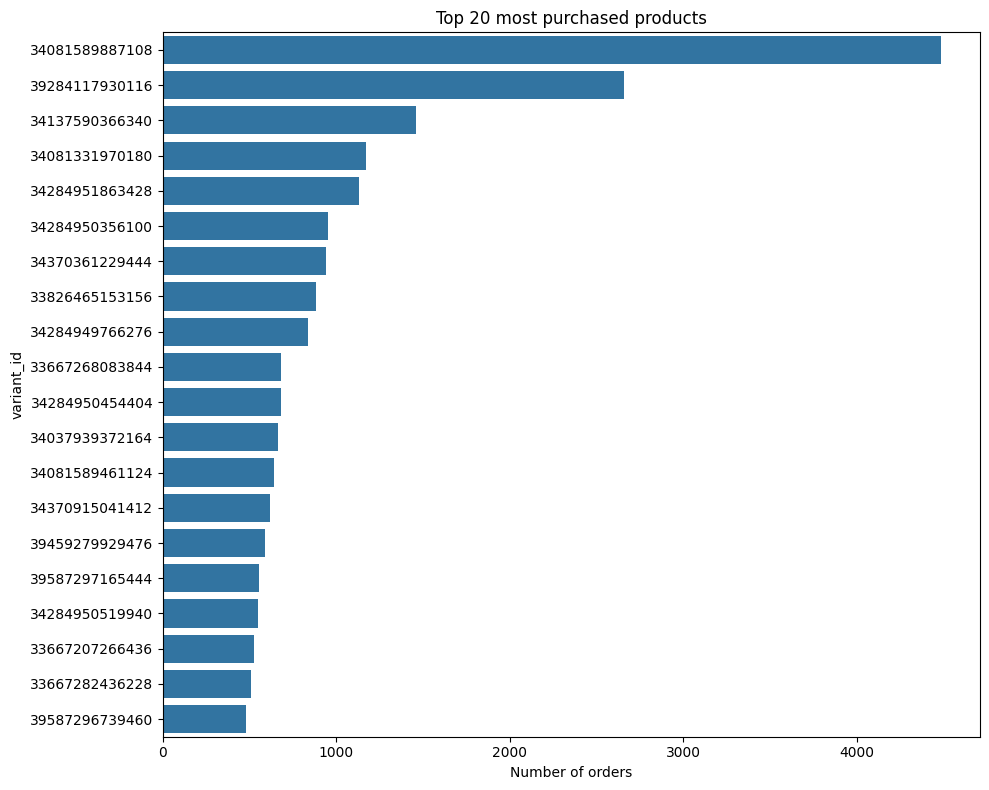

In [61]:
products_most_purchased['variant_id'] = products_most_purchased['variant_id'].astype(str)
fig, ax = plt.subplots(figsize=(10, 8))
sns.barplot(data = products_most_purchased, x = 'num_orders', y='variant_id')
ax.set_title('Top 20 most purchased products')
ax.set_xlabel('Number of orders')
plt.tight_layout()
plt.show()


**INSIGHT 1:**
- The most purchased product by far is Oatly long-life-milk-substitutes (4,487 orders).
- There are products in orders that do not exist in inventory, suggesting discontinued products or incomplete catalogue data.

#### Which products are most added to regulars?

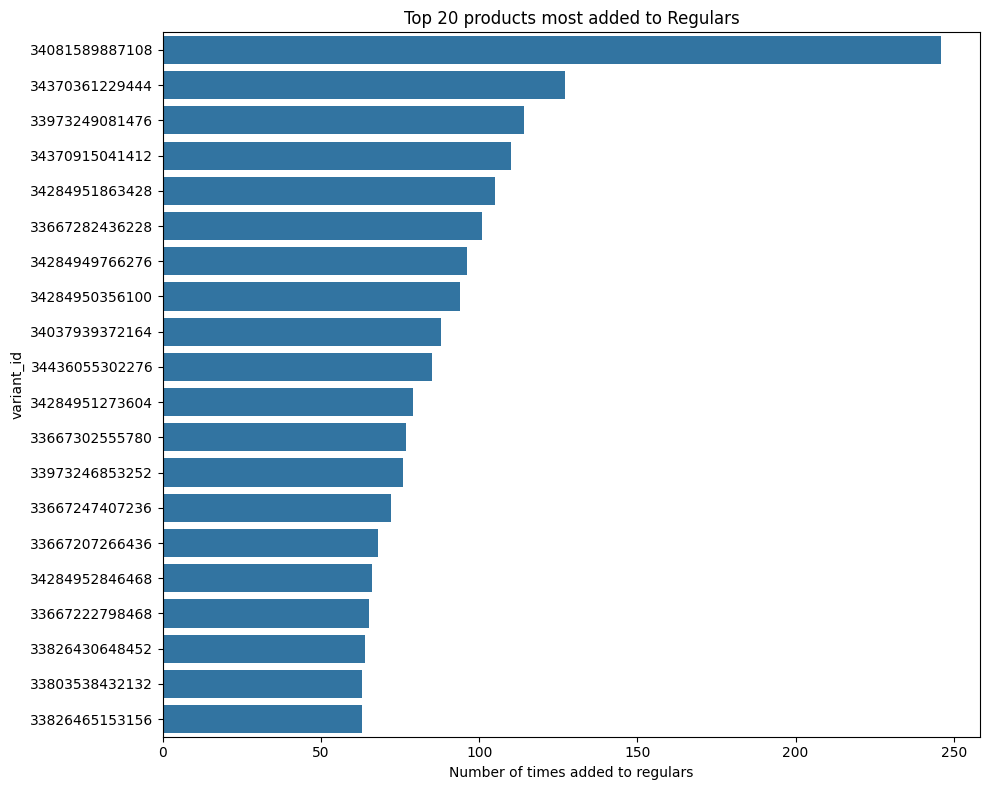

In [62]:
regulars_most_populars = regulars.groupby('variant_id')['variant_id'].size()\
                                .sort_values(ascending = False)\
                                .head(20)\
                                .reset_index(name= 'count')

fig, ax = plt.subplots(figsize=(10, 8))
sns.barplot(data = regulars_most_populars, x = 'count', y='variant_id')
ax.set_title('Top 20 products most added to Regulars')
ax.set_xlabel('Number of times added to regulars')
plt.tight_layout()
plt.show()

**INSIGHT 2:**
- The most purchased product is also the most added to regulars by far. However, the top 20 of both lists do not fully overlap, suggesting that some products are bought occasionally but not considered a regular purchase, and vice versa.

#### Do users with more orders have more items in regulars?

In [63]:
orders_by_user = orders.groupby('user_id').size().reset_index(name='num_orders')
regulars_by_user = regulars.groupby('user_id').size().reset_index(name='num_regulars')

correlation = orders_by_user.merge(regulars_by_user, on='user_id', how='left').fillna(0)

print(f"Users with regulars: {regulars_by_user['user_id'].nunique()} ({regulars_by_user['user_id'].nunique()/orders_by_user['user_id'].nunique()*100:.1f}%)")
print(correlation[['num_orders', 'num_regulars']].corr())

Users with regulars: 1448 (29.1%)
              num_orders  num_regulars
num_orders      1.000000      0.246099
num_regulars    0.246099      1.000000


**INSIGHT 3:**
- Only 29% of users use the regulars feature.
- The correlation between number of orders and products in regulars is low (0.25).
- Using regulars is not a widespread behaviour among loyal users — it is a feature adopted only by a minority.

#### Which products are most abandoned in the cart?

In [64]:
products_most_abandoned = abandoned_carts.explode('variant_id')\
    .groupby('variant_id')['id'].size()\
    .sort_values(ascending=False)\
    .head(20)\
    .reset_index()\
    .rename(columns={'item_ids': 'variant_id', 'id': 'number_of_abandons'})\
    .merge(inventory[['variant_id', 'vendor', 'product_type', 'price']], 
           on='variant_id', how='left')

products_most_abandoned

,variant_id,number_of_abandons,vendor,product_type,price
0,34081589887108,608,oatly,long-life-milk-substitutes,10.79
1,34284951863428,478,plenty,toilet-roll-kitchen-roll-tissue,3.69
2,34284950356100,409,fairy,dishwashing,1.99
3,34137590366340,395,NaN,NaN,NaN
4,34284949766276,382,andrex,toilet-roll-kitchen-roll-tissue,8.49
5,34284950519940,307,fairy,dishwashing,9.99
6,34284950454404,306,lenor,fabric-softener-freshener,3.99
7,39459279929476,305,colgate,dental,2.99
8,39284117930116,298,NaN,NaN,NaN
9,34037939372164,290,andrex,toilet-roll-kitchen-roll-tissue,4.99


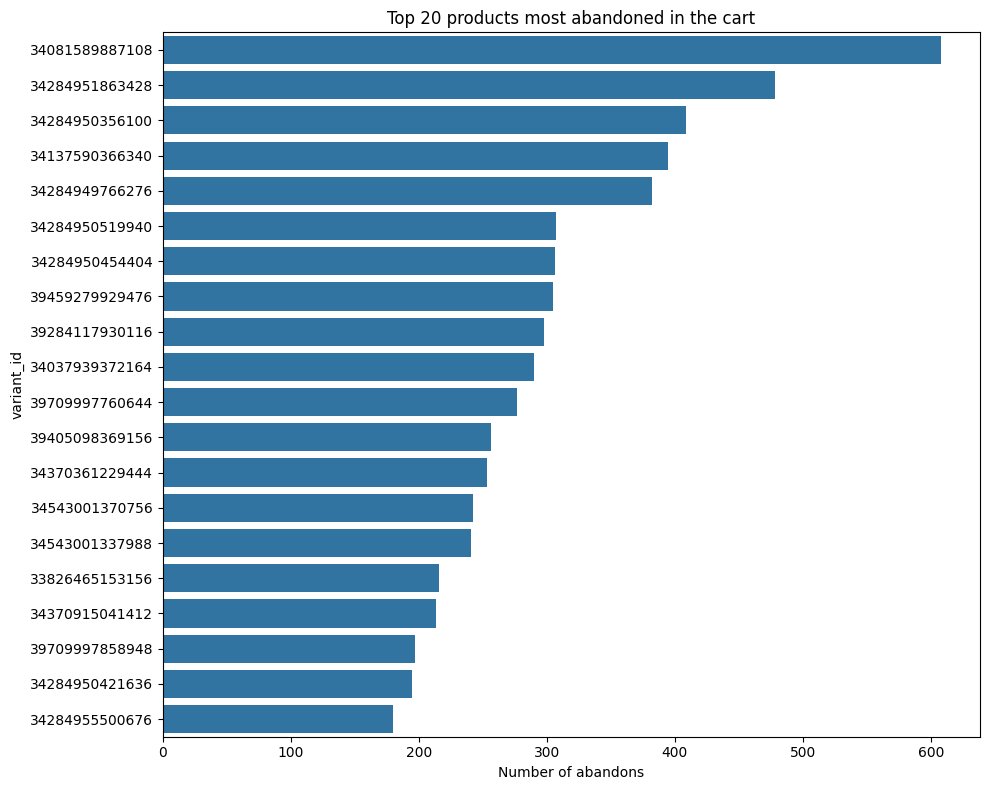

In [65]:
products_most_abandoned['variant_id'] = products_most_abandoned['variant_id'].astype(str)
fig, ax = plt.subplots(figsize=(10, 8))
sns.barplot(data = products_most_abandoned, x = 'number_of_abandons', y='variant_id')
ax.set_title('Top 20 products most abandoned in the cart')
ax.set_xlabel('Number of abandons')
plt.tight_layout()
plt.show()


In [66]:
ratio = products_most_purchased.merge(
   products_most_abandoned[['variant_id', 'number_of_abandons']], 
    on='variant_id', 
    how='inner'
).assign(ratio=lambda x: x['number_of_abandons'] / x['num_orders'])\
 .sort_values('ratio', ascending=False)

print(ratio[['variant_id', 'vendor', 'num_orders', 'number_of_abandons', 'ratio']].head(10))


        variant_id         vendor  num_orders  number_of_abandons     ratio
12  34284950519940          fairy         551                 307  0.557169
11  39459279929476        colgate         588                 305  0.518707
7   34284949766276         andrex         838                 382  0.455847
8   34284950454404          lenor         683                 306  0.448023
9   34037939372164         andrex         663                 290  0.437406
4   34284950356100          fairy         954                 409  0.428721
3   34284951863428         plenty        1133                 478  0.421889
10  34370915041412          mutti         620                 213  0.343548
2   34137590366340            NaN        1459                 395  0.270733
5   34370361229444  whogivesacrap         939                 253  0.269436


**INSIGHT 4:**
- The most abandoned products are also the most purchased, confirming that abandonment volume is linked to product popularity.
- Fairy and Colgate have the highest ratios (0.56 and 0.52), suggesting that users consider them but hesitate due to price or look for alternatives.


#### Are the users who abandon the most also the most active ones?

In [67]:
orders_by_user = orders.groupby('user_id').size().reset_index(name='num_orders')

abandons_by_user = abandoned_carts.groupby('user_id').size().reset_index(name='num_abandons')

cross = orders_by_user.merge(abandons_by_user, on='user_id', how='inner')\
    .sort_values('num_abandons', ascending=False)

print(cross.head(10))


                                                user_id  num_orders  \
497   257be7ae940425880bbb20bf162c2616b32881bf0a8bda...          21   
399   1dacfd2a360677052d8605f843ae410dd23b0ddb7f506c...          18   
3438  fffd9f989509e36d1fc3e3e53627d6341482f385052a03...           9   
2041  97e81469f5758878f4d7eaa3af6b4fc37b2b5c22558811...           6   
227   111d37baa4fb9dde7c557b4057dfd7eff8205dc0e27190...           8   
270   14be3833c19e0a1fd7e6db0e5375a3d1dcc9efafcb0e69...          11   
2492  ba7176c5f870cd86e51ecc4375e0becc8cc305845e70b9...          25   
2166  a124c8bb0453ea0957405b7a08a7fd377247bac054a097...           6   
2264  a8ea4d1ff9cfc5005b7354d1d17564347dd842bab2a6c3...          11   
1576  75c6f146a0925fedd1793b3ecd7775f2500a44ed6af6fc...          16   

      num_abandons  
497             10  
399              9  
3438             7  
2041             7  
227              7  
270              7  
2492             7  
2166             7  
2264             7  
1576    

**INSIGHT 5:**
- Users who abandon carts the most are also the most active buyers. The user with the most abandons (10) has 21 orders, and the second (9 abandons) has 18 orders.
- Abandoning the cart is part of the purchase decision process, not a sign of disengagement.

### Users

#### Orders by users

In [68]:
orders_by_user = orders.groupby('user_id')['id'].count()
print(orders_by_user.describe())
print(f"\nUsers with only 1 order: {(orders_by_user == 1).sum()}")
print(f"Users with more than 5 orders: {(orders_by_user > 5).sum()}")

count    4983.000000
mean        1.760586
std         1.936537
min         1.000000
25%         1.000000
50%         1.000000
75%         2.000000
max        25.000000
Name: id, dtype: float64

Users with only 1 order: 3572
Users with more than 5 orders: 225


**INSIGHT 6:**
- 71.7% of users (3,572 out of 4,983) have placed only 1 order.
- Only 4.5% have more than 5 orders.
- The median is 1 order, confirming that the majority are occasional users.

#### Which users spend the most?

In [69]:
spend_by_user = orders.explode('ordered_items')\
    .rename(columns={'ordered_items':'variant_id'})\
    .merge(inventory[['variant_id', 'price']], on = 'variant_id', how= 'left')\
    .groupby('user_id')['price'].sum()\
    .sort_values(ascending = False)\
    .reset_index()\
    .rename(columns= {'price': 'total_spend'})


spend_by_user.head(20)

,user_id,total_spend
0,04e9d7967f4dfd7d40175f130f1c80f62204ff697df92d...,1969.99
1,ba7176c5f870cd86e51ecc4375e0becc8cc305845e70b9...,1781.73
2,a655b992a3ee5f6aa9f5ab5662c4befac1fdc45c99885b...,1756.21
3,751784f6b91585570748d781931f56e3ca71fc92bca034...,1738.17
4,425c2b5dc3f35d7e690d26b2028201385d622599043c4d...,1617.47
5,c1e8d257fc94a13b84dcf4e21e05a5872cd9c1683f6647...,1537.11
6,1dacfd2a360677052d8605f843ae410dd23b0ddb7f506c...,1485.52
7,300362d588ff3c7d720d58b04281edc30f1f74b2b86af2...,1455.09
8,b9452236b95ed2b60d18404a1e8b5aa4652bc3c4518a6e...,1402.88
9,114e78a8909ad3f9d481e66563998301eff9e7cd1b2d00...,1320.23


**INSIGHT 7:**
- The highest-spending user accumulates £1,969 in total.
- There is a small group of users with spending well above the average, confirming the skewed distribution seen in the boxplot by segment.

#### Are there differences between Top Up vs Proposition segments?


In [70]:
spend_by_segment = spend_by_user\
    .merge(users[['user_id', 'user_segment']], on='user_id', how='left')\
    .groupby('user_segment')['total_spend'].agg(['mean', 'median', 'sum'])

spend_by_segment

,mean,median,sum
user_segment,,,
Proposition,106.877829,54.72,250094.12
Top Up,90.700541,52.59,239721.53


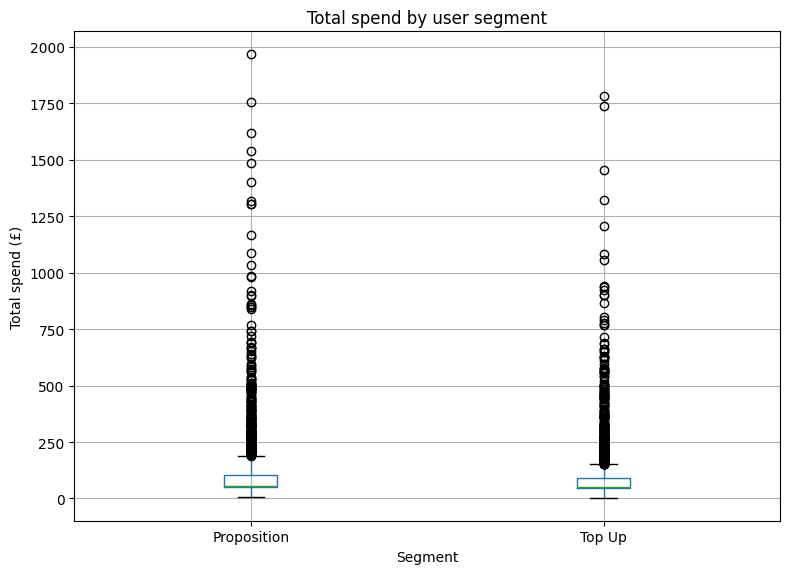

In [71]:
fig, ax = plt.subplots(figsize=(8, 6))
spend_by_user.merge(users[['user_id', 'user_segment']], on='user_id', how='left')\
    .boxplot(column='total_spend', by='user_segment', ax=ax)
ax.set_title('Total spend by user segment')
ax.set_xlabel('Segment')
ax.set_ylabel('Total spend (£)')
plt.suptitle('')
plt.tight_layout()
plt.show()

**INSIGHT 8:**
- Proposition users spend on average 18% more than Top Up users (£106 vs £90).
- However, the median is similar in both segments, indicating that the difference comes from a small group of Proposition users who spend significantly more, not from all of them.
- There are many outliers in both segments — users with spending well above the average.

### Additional Insights

#### How has sales volume evolved over time?

In [72]:
orders.order_date.max()

Timestamp('2022-03-14 00:00:00')

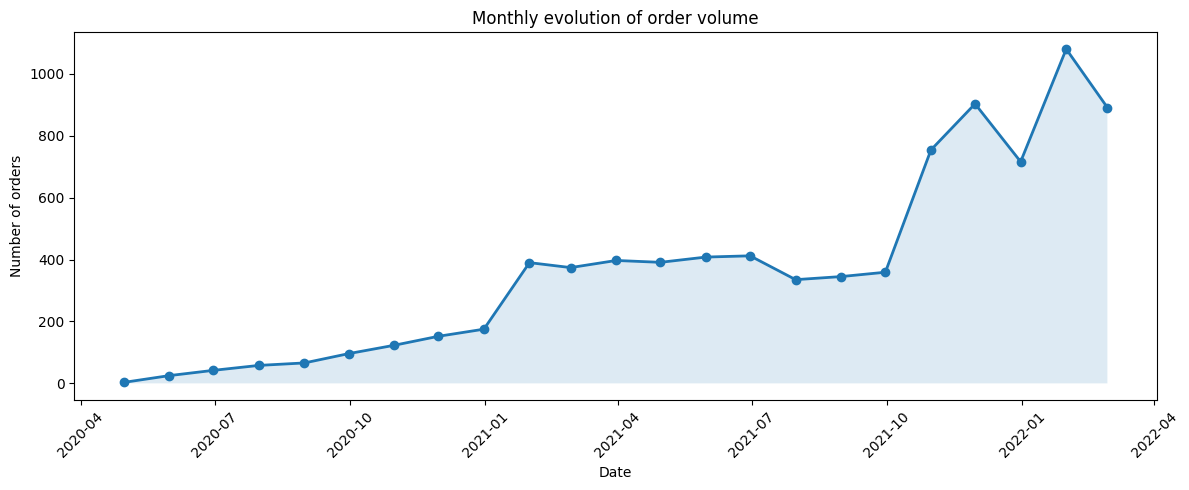

In [73]:
orders['order_date'] = pd.to_datetime(orders['order_date'])

monthly_sales = orders[orders['order_date'] < '2022-03-01']\
    .resample('ME', on='order_date').size().reset_index(name='num_orders')

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(monthly_sales['order_date'], monthly_sales['num_orders'], marker='o', linewidth=2)
ax.fill_between(monthly_sales['order_date'], monthly_sales['num_orders'], alpha=0.15)
ax.set_title('Monthly evolution of order volume')
ax.set_xlabel('Date')
ax.set_ylabel('Number of orders')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**INSIGHT 9:**
- Orders grew steadily from 2020 to early 2022.
- A significant spike is observed in early 2021 and another one in late 2021.

#### Are users who fill in their household profile more loyal?

In [74]:
users['has_profile'] = users['count_people'].notna()

pct_profile = users['has_profile'].mean() * 100
print(f'Users with household profile: {pct_profile:.1f}%')

print(users[users['has_profile']][['count_people', 'count_adults', 'count_children', 'count_pets']].mean())

# Loyalty
orders_by_user = orders.groupby('user_id')['id'].count().reset_index(name='num_orders')

loyalty = orders_by_user.merge(users[['user_id', 'has_profile']], on='user_id', how='left')\
    .groupby('has_profile')['num_orders'].mean()
print(loyalty)

Users with household profile: 6.5%
count_people      2.787692
count_adults      2.003077
count_children    0.707692
count_pets        0.636923
dtype: float64
has_profile
False    1.719193
True     2.353846
Name: num_orders, dtype: float64


**INSIGHT 10:**
- Only 6.5% of users have filled in their household profile.
- Of those who did, the average household size is 2.8 people, with a notable presence of children (0.71 on average) and pets (0.64 on average), confirming a family-oriented customer profile.
- Users who have filled in their profile place on average 37% more orders (2.35 vs 1.72), suggesting they are more engaged with the platform.

#### Inventory Analysis

In [75]:
inventory

,variant_id,price,compare_at_price,vendor,product_type,tags
0,39587297165444,3.09,3.15,heinz,condiments-dressings,"[table-sauces, vegan]"
1,34370361229444,4.99,5.50,whogivesacrap,toilet-roll-kitchen-roll-tissue,"[b-corp, eco, toilet-rolls]"
2,34284951863428,3.69,3.99,plenty,toilet-roll-kitchen-roll-tissue,[kitchen-roll]
3,33667283583108,1.79,1.99,thecheekypanda,toilet-roll-kitchen-roll-tissue,"[b-corp, cruelty-free, eco, tissue, vegan]"
4,33803537973380,1.99,2.09,colgate,dental,[dental-accessories]
...,...,...,...,...,...,...
1728,39539419218052,4.99,5.99,bother,,[household-sundries]
1729,34534187368580,4.69,5.49,tommeetippee,baby-accessories,[feeding-weaning]
1730,33826439594116,15.39,17.15,colief,baby-accessories,[feeding-weaning]
1731,33667214508164,19.49,21.65,enterosgel,medicines-treatments,"[discontinue, first-aid]"


In [76]:
print(f"Products with price 0: {(inventory['price'] == 0).sum()}")
print(f"Products sold below compare at price: {(inventory['compare_at_price'] > inventory['price']).mean()*100:.1f}%")

Products with price 0: 71
Products sold below compare at price: 93.7%


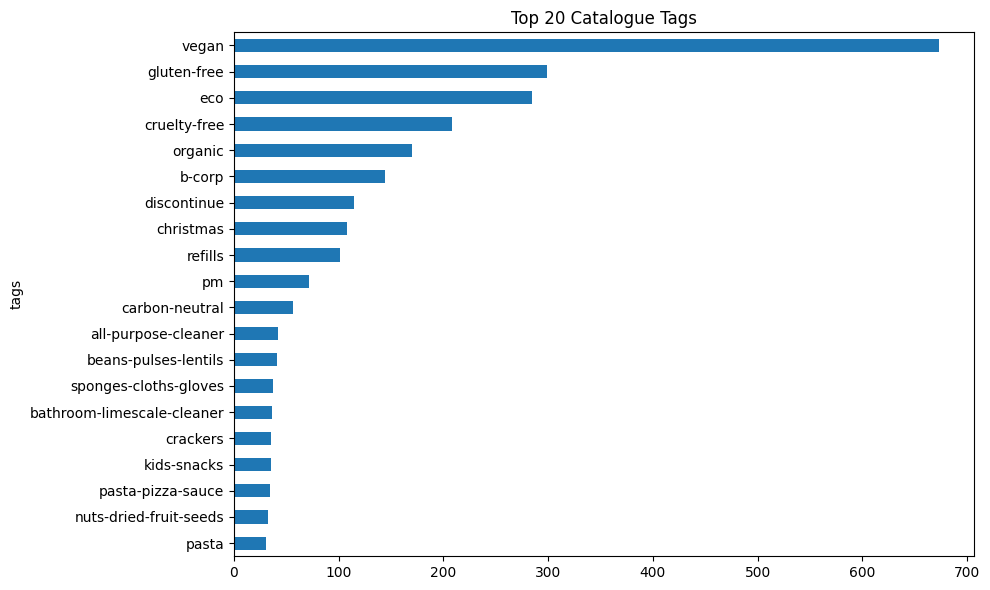

In [77]:
inventory.explode('tags')['tags'].value_counts().head(20).sort_values().plot.barh(figsize=(10, 6), title='Top 20 Catalogue Tags')
plt.tight_layout()
plt.show()

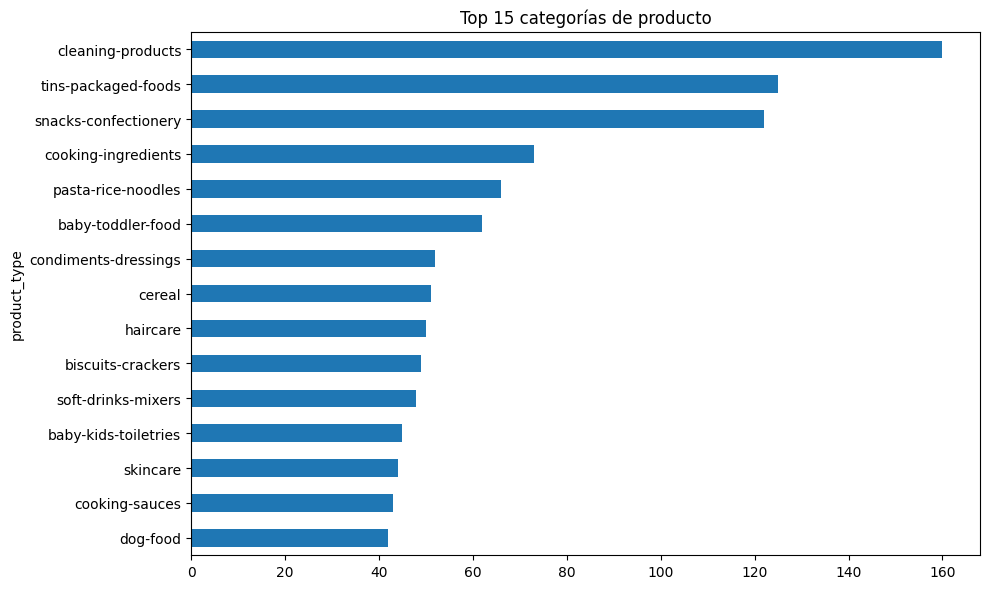

In [78]:
inventory['product_type'].value_counts().head(15).sort_values().plot.barh(figsize=(10, 6), title='Top 15 categorías de producto')
plt.tight_layout()
plt.show()

**INSIGHT 11:**
- 71 products (4.1%) have a price of 0 in inventory and none appear in orders — these are likely products pending activation or test entries.
- 93.7% of products have a compare_at_price higher than price, although the exact meaning of this column is not documented.
- The catalogue is clearly oriented towards sustainable products: vegan is the most frequent tag, followed by gluten-free, eco, cruelty-free and organic.
- There is significant presence of baby and pet categories, confirming a family-oriented customer profile.

## Conclusions

The exploratory data analysis allows us to draw the following conclusions about the business.

**User Retention**
- 71.7% of users place only one order and just 4.5% have more than 5 orders, suggesting a potential retention problem.
- Users who fill in their household profile place on average 37% more orders, although only 6.5% of users do so.

**Purchase Behaviour**
- Cart abandonment should not be interpreted as a negative signal: the users who abandon the most are also the most active buyers. It is a behaviour typical of engaged platform users.

**Star Product**
- Oatly is the most purchased product (4,487 orders) and the most added to regulars, with the lowest abandonment ratio. It is clearly the reference product of the catalogue.

**Segment Differences**
- Proposition users spend on average 18% more than Top Up users (£106 vs £90), although the median is similar in both segments, indicating that the difference comes from a small group of high-value users.

**Catalogue**
- The catalogue is oriented towards sustainable and ethical products. There is significant presence of baby and pet categories, confirming a family-oriented customer profile.

**Growth**
- Order volume grew steadily from 2020 to early 2022, with significant spikes in early and late 2021.

**Future Work:**
- Analyse why 71.7% of users do not return and what levers could improve retention.
- Investigate whether incentivising the use of regulars can increase purchase frequency.
- Deep dive into the high-value user segment to understand what drives their loyalty.
- Analyse the 2021 growth spikes in more detail.
- Investigate products that appear in orders but not in inventory.